### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

(array([0.96107306, 1.03645134, 0.71609365, 0.55591481, 0.52764795,
        0.63129309, 0.45226968, 0.60302623, 0.30151312, 0.33920226,
        0.30151312, 0.36746911, 0.28266855, 0.23555712, 0.22613484,
        0.1884457 , 0.1884457 , 0.13191199, 0.10364513, 0.16960113,
        0.10364513, 0.16960113, 0.13191199, 0.06595599, 0.04711142,
        0.03768914, 0.05653371, 0.02826685, 0.03768914, 0.03768914,
        0.06595599, 0.02826685, 0.03768914, 0.04711142, 0.03768914,
        0.00942228, 0.01884457, 0.00942228, 0.03768914, 0.01884457,
        0.00942228, 0.01884457, 0.00942228, 0.        , 0.00942228,
        0.00942228, 0.        , 0.00942228, 0.        , 0.00942228]),
 array([5.23764838e-04, 1.06655134e-01, 2.12786504e-01, 3.18917873e-01,
        4.25049243e-01, 5.31180612e-01, 6.37311982e-01, 7.43443351e-01,
        8.49574721e-01, 9.55706090e-01, 1.06183746e+00, 1.16796883e+00,
        1.27410020e+00, 1.38023157e+00, 1.48636294e+00, 1.59249431e+00,
        1.69862568e+00, 1.8047

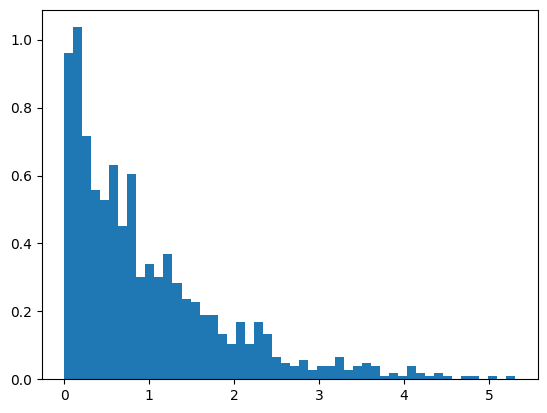

In [5]:
# Step 1: generare 1000 valori casuali da una distribuzione gamma
dist = sp.stats.gamma(a=1)
sample = dist.rvs(size=1000)
# sample.shape                             # così otteniami un array flat, ma in questo caso non ci serve
plt.hist(sample, bins=50, density=True)    # già con sample ci da l'istogramma, ma aggiungiamo anche bins e density

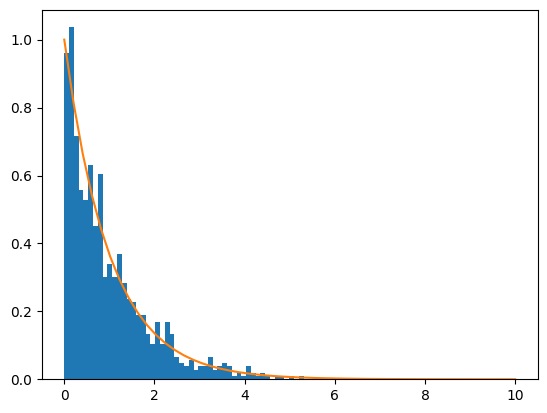

In [6]:
# Step 2: istogramma campione più PDF
plt.hist(sample, bins=50, density=True)
x = np.linspace(0,10)
plt.plot(x, dist.pdf(x))

In [7]:
# Step 3: stima il parameto di forma del campione
sp.stats.gamma.fit(sample)

(np.float64(0.9982664142663349),
 np.float64(0.0005237648379497492),
 np.float64(0.9751249084610321))

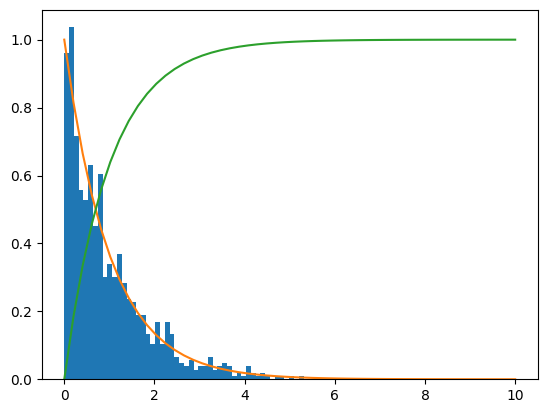

In [8]:
# Step 4: distribuzione della funzioane cumulativa 
plt.hist(sample, bins=50, density=True)
plt.plot(x, dist.pdf(x))
cdf = dist.cdf(x)
plt.plot(x, cdf)

In [9]:
# Step 5: calcolare la varianza
varianza = np.var(sample)
print("Varianza: ", varianza)

Varianza:  0.8627057439692436


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

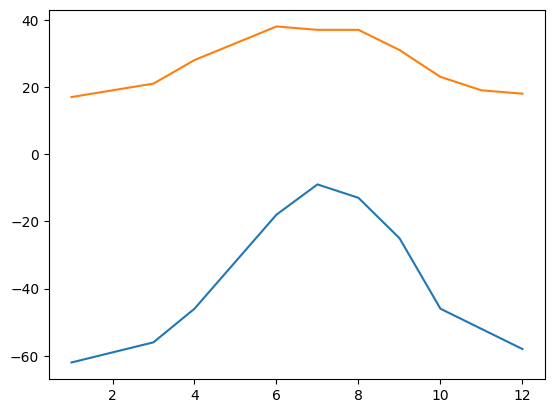

In [10]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

months = np.arange(1, 13)
plt.plot(months, temp_min)
plt.plot(months, temp_max)

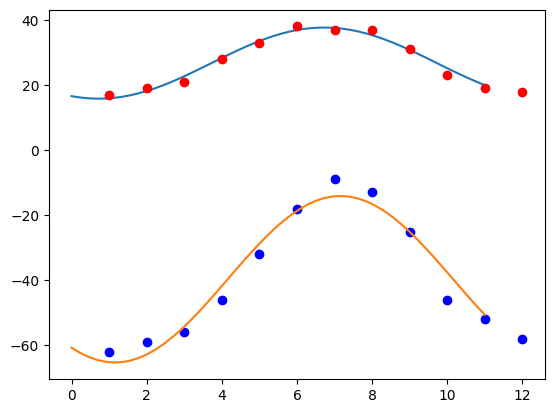

In [11]:
def polinomio_grado3(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

def sin(x, a, b, c):
    return c + a*np.sin((x+b)*2*np.pi/12)

params_max, _ = sp.optimize.curve_fit(sin, months, temp_max)  # con , _ ritorna solo i primi elementi
params_min, _ = sp.optimize.curve_fit(sin, months, temp_min)

x = np.linspace(0, 11)
plt.plot(x, sin(x, *params_max))
plt.plot(months, temp_max, "ro")

plt.plot(months, temp_min, "bo")
plt.plot(x, sin(x, *params_min))

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [12]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


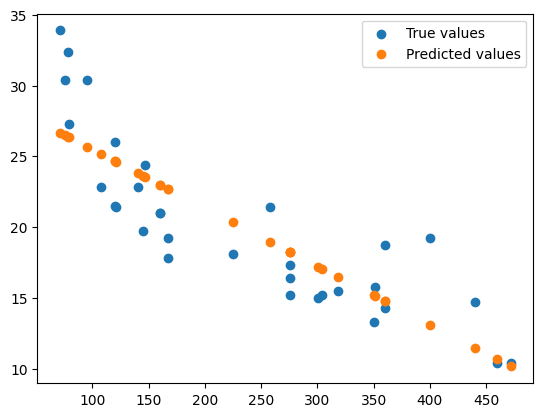

In [15]:
# Dataframe:
x = df['disp']
y = df['mpg']
slope, intercept, *_ = sp.stats.linregress(x, y)

y_pred = slope*x + intercept

plt.scatter(x, y, label='True values')
plt.scatter(x, y_pred, label='Predicted values')
plt.legend()
plt.show()